# TARDIS — Steps 1 & 2 : nettoyage, exploration et analyse

Ce notebook couvre les deux premieres etapes du projet.

La partie 1 charge `dataset.csv`, le nettoie, cree de nouvelles variables
et enregistre le resultat dans `cleaned_dataset.csv`.

La partie 2 repart de ce fichier nettoye, calcule des statistiques
descriptives, trace des graphiques et donne une interpretation ecrite
apres chaque resultat.

---

# Partie 1 — Data Exploration & Cleaning

Objectif : passer d'un fichier brut sali a un jeu de donnees exploitable,
sans valeur manquante ni doublon, avec des types corrects et des variables
utiles pour la suite.

## 1. Imports, chargement et inspection du dataset

`pandas` sert a manipuler le tableau de donnees, `numpy` fournit les bornes
infinies utilisees plus loin pour decouper les valeurs en categories.

`pd.read_csv()` lit un fichier CSV et le transforme en tableau, appele DataFrame.

Deux arguments comptent ici :

- `sep=";"` parce que dans ce fichier les colonnes sont separees par des
  points-virgules et non par des virgules
- `dtype=str` force le chargement de tout le fichier en texte. On veut voir les
  valeurs telles qu'elles sont ecrites avant de convertir quoi que ce soit, sinon
  pandas devine les types et detruit silencieusement les valeurs mal formatees

`.shape` donne la taille du tableau sous la forme (nombre de lignes, nombre de colonnes).

In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv("dataset.csv", sep=";", dtype=str)

print("Taille du dataset :", df.shape)

Taille du dataset : (12070, 26)


### 1.1 Apercu des premieres lignes

`.head()` affiche les 5 premieres lignes, pour voir a quoi ressemblent les donnees.

In [2]:
df.head()

,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Cancellation comments,Number of trains delayed at departure,Average delay of late trains at departure,...,Number of trains delayed > 15min,Average delay of trains > 15min (if competing with flights),Number of trains delayed > 30min,Number of trains delayed > 60min,Pct delay due to external causes,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965


### 1.2 Structure et types des colonnes

`.info()` affiche la liste des colonnes, leur type et le nombre de valeurs remplies.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 26 columns):
 #   Column                                                                         Non-Null Count  Dtype
---  ------                                                                         --------------  -----
 0   Date                                                                           12010 non-null  str  
 1   Service                                                                        11830 non-null  str  
 2   Departure station                                                              12011 non-null  str  
 3   Arrival station                                                                12011 non-null  str  
 4   Average journey time                                                           11830 non-null  str  
 5   Number of scheduled trains                                                     11830 non-null  str  
 6   Number of cancelled trains                       

### 1.3 Comptage des valeurs manquantes

`.isna()` met `True` partout ou la valeur est manquante, `.sum()` additionne ces
`True` et donne donc le nombre de valeurs manquantes de chaque colonne.

In [4]:
print(df.isna().sum())

Date                                                                                60
Service                                                                            240
Departure station                                                                   59
Arrival station                                                                     59
Average journey time                                                               240
Number of scheduled trains                                                         240
Number of cancelled trains                                                         239
Cancellation comments                                                            11493
Number of trains delayed at departure                                              240
Average delay of late trains at departure                                          239
Average delay of all trains at departure                                           241
Departure delay comments                   

### 1.4 Comptage des lignes en double

`.duplicated()` met `True` sur chaque ligne qui existe deja plus haut dans le
tableau, `.sum()` compte ces `True` et donne le nombre de lignes en double.

In [5]:
print("Nombre de lignes en double :", df.duplicated().sum())

Nombre de lignes en double : 174


### 1.5 Bilan des problemes detectes

L'inspection revele que le fichier a ete volontairement sali :

- des valeurs manquantes dans presque toutes les colonnes
- 174 lignes en double
- toutes les colonnes sont du texte, meme celles qui contiennent des nombres
- les nombres sont pollues : `5,04`, `163.0 min`, `16.67%`, des espaces en trop
- la colonne Date a cinq formats : `2018-01`, `2018/01`, `2018 01`, `01-2018`, `2018-01 `
- les gares sont ecrites de plusieurs facons : `LE MANS`, `le mans`, ` LE MANS `

Le reste du notebook corrige ces problemes dans l'ordre.

## 2. Renommage des colonnes

Les noms d'origine sont longs et contiennent des espaces, des parentheses et le
signe `>`. Impossible d'ecrire `df.Average journey time`.

On construit un dictionnaire, ancien nom a gauche et nouveau nom a droite, puis
`.rename(columns=...)` remplace les noms en suivant ce dictionnaire.

`.columns` donne la liste des noms de colonnes, `list()` l'affiche proprement.

In [6]:
nouveaux_noms = {
    "Date": "date",
    "Service": "service",
    "Departure station": "departure_station",
    "Arrival station": "arrival_station",
    "Average journey time": "journey_time",
    "Number of scheduled trains": "nb_scheduled",
    "Number of cancelled trains": "nb_cancelled",
    "Cancellation comments": "cancel_comment",
    "Number of trains delayed at departure": "nb_delayed_dep",
    "Average delay of late trains at departure": "avg_delay_late_dep",
    "Average delay of all trains at departure": "avg_delay_all_dep",
    "Departure delay comments": "dep_comment",
    "Number of trains delayed at arrival": "nb_delayed_arr",
    "Average delay of late trains at arrival": "avg_delay_late_arr",
    "Average delay of all trains at arrival": "avg_delay_all_arr",
    "Arrival delay comments": "arr_comment",
    "Number of trains delayed > 15min": "nb_delayed_15",
    "Average delay of trains > 15min (if competing with flights)": "avg_delay_15",
    "Number of trains delayed > 30min": "nb_delayed_30",
    "Number of trains delayed > 60min": "nb_delayed_60",
    "Pct delay due to external causes": "pct_cause_external",
    "Pct delay due to infrastructure": "pct_cause_infra",
    "Pct delay due to traffic management": "pct_cause_traffic",
    "Pct delay due to rolling stock": "pct_cause_rolling_stock",
    "Pct delay due to station management and equipment reuse": "pct_cause_station",
    "Pct delay due to passenger handling (crowding, disabled persons, connections)": "pct_cause_passenger",
}

df = df.rename(columns=nouveaux_noms)

print(list(df.columns))

['date', 'service', 'departure_station', 'arrival_station', 'journey_time', 'nb_scheduled', 'nb_cancelled', 'cancel_comment', 'nb_delayed_dep', 'avg_delay_late_dep', 'avg_delay_all_dep', 'dep_comment', 'nb_delayed_arr', 'avg_delay_late_arr', 'avg_delay_all_arr', 'arr_comment', 'nb_delayed_15', 'avg_delay_15', 'nb_delayed_30', 'nb_delayed_60', 'pct_cause_external', 'pct_cause_infra', 'pct_cause_traffic', 'pct_cause_rolling_stock', 'pct_cause_station', 'pct_cause_passenger']


## 3. Nettoyage des colonnes texte

La meme gare est ecrite de plusieurs facons. Tant qu'on ne les uniformise pas,
` LYON PART DIEU ` et `LYON PART DIEU` sont deux gares differentes pour pandas,
donc deux categories differentes pour le modele et deux entrees dans le menu
deroulant du dashboard.

Les methodes appliquees :

- `.unique()` donne la liste des valeurs differentes, `len()` compte combien il y en a
- `.str.strip()` enleve les espaces au debut et a la fin du texte
- `.str.upper()` met tout en majuscules, pour que `le mans` et `LE MANS` deviennent identiques
- `.str.replace("SAINT", "ST")` regle le dernier cas : `MARSEILLE SAINT CHARLES` et
  `MARSEILLE ST CHARLES` sont la meme gare

Le compteur avant et apres mesure l'effet du nettoyage : 133 gares distinctes
avant, 61 apres.

In [7]:
print("Gares differentes avant :", len(df["departure_station"].unique()))

df["departure_station"] = df["departure_station"].str.strip().str.upper()
df["arrival_station"] = df["arrival_station"].str.strip().str.upper()
df["service"] = df["service"].str.strip().str.upper()

df["departure_station"] = df["departure_station"].str.replace(
    "SAINT", "ST", regex=False
)
df["arrival_station"] = df["arrival_station"].str.replace("SAINT", "ST", regex=False)

print("Gares differentes apres :", len(df["departure_station"].unique()))

Gares differentes avant : 133
Gares differentes apres : 61


## 4. Conversion des colonnes en nombres

Dix-neuf colonnes doivent contenir des nombres mais sont chargees en texte, avec
quatre defauts differents. Une boucle `for` applique le meme traitement a chacune.

Ordre des operations, chaque etape reglant un defaut observe :

- `.str.strip()` enleve les espaces autour de la valeur : `" 6.51 "` devient `"6.51"`
- `.str.replace(" min", "")` enleve l'unite : `"163.0 min"` devient `"163.0"`
- `.str.replace("%", "")` enleve le symbole : `"16.67%"` devient `"16.67"`
- `.str.replace(",", ".")` corrige la decimale francaise : `"5,04"` devient `"5.04"`
- `pd.to_numeric()` transforme enfin le texte en nombre

L'argument `errors="coerce"` fait passer a `NaN`, c'est-a-dire vide, ce qui reste
inconvertible, au lieu de faire planter le notebook.

L'ordre compte. Si `pd.to_numeric` passait avant les `.replace`, il transformerait
`"5,04"` en `NaN` et le nettoyage arriverait trop tard, sur une valeur deja
detruite.

`.dtypes` affiche le type de chaque colonne, on verifie qu'on obtient bien des
`float64`.

In [8]:
colonnes_nombres = [
    "journey_time",
    "nb_scheduled",
    "nb_cancelled",
    "nb_delayed_dep",
    "avg_delay_late_dep",
    "avg_delay_all_dep",
    "nb_delayed_arr",
    "avg_delay_late_arr",
    "avg_delay_all_arr",
    "nb_delayed_15",
    "avg_delay_15",
    "nb_delayed_30",
    "nb_delayed_60",
    "pct_cause_external",
    "pct_cause_infra",
    "pct_cause_traffic",
    "pct_cause_rolling_stock",
    "pct_cause_station",
    "pct_cause_passenger",
]

for col in colonnes_nombres:
    df[col] = df[col].str.strip()
    df[col] = df[col].str.replace(" min", "", regex=False)
    df[col] = df[col].str.replace("%", "", regex=False)
    df[col] = df[col].str.replace(",", ".", regex=False)
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[colonnes_nombres].dtypes)

journey_time               float64
nb_scheduled               float64
nb_cancelled               float64
nb_delayed_dep             float64
avg_delay_late_dep         float64
avg_delay_all_dep          float64
nb_delayed_arr             float64
avg_delay_late_arr         float64
avg_delay_all_arr          float64
nb_delayed_15              float64
avg_delay_15               float64
nb_delayed_30              float64
nb_delayed_60              float64
pct_cause_external         float64
pct_cause_infra            float64
pct_cause_traffic          float64
pct_cause_rolling_stock    float64
pct_cause_station          float64
pct_cause_passenger        float64
dtype: object

## 5. Conversion de la colonne date

La colonne contient cinq formats. On les ramene a deux, puis on convertit.

Premiere etape, uniformiser les separateurs. `.str.replace("/", "-")` et
`.str.replace(" ", "-")` transforment `2018/01` et `2018 01` en `2018-01`.
`.str.strip()` traite le cas `2018-01 ` avec un espace en fin.

Il reste alors deux formats : annee-mois (`2018-01`) et mois-annee (`01-2018`).

Deuxieme etape, `pd.to_datetime()` transforme le texte en vraie date.
L'argument `format="%Y-%m"` signifie annee sur 4 chiffres puis mois, et
`errors="coerce"` met `NaT`, une date vide, quand le format ne correspond pas.
On fait donc un premier essai avec ce format, puis un deuxieme essai avec
`format="%m-%Y"` pour recuperer les valeurs comme `01-2018`.

`.fillna()` remplit les trous du premier essai avec les valeurs du second.
Sans cette double passe, les 77 lignes ecrites en mois-annee seraient perdues.

`.min()` et `.max()` donnent la plus ancienne et la plus recente date, pour
verifier que la periode couverte est plausible.

In [9]:
df["date"] = df["date"].str.strip()
df["date"] = df["date"].str.replace("/", "-", regex=False)
df["date"] = df["date"].str.replace(" ", "-", regex=False)

date_annee_mois = pd.to_datetime(df["date"], format="%Y-%m", errors="coerce")
date_mois_annee = pd.to_datetime(df["date"], format="%m-%Y", errors="coerce")

df["date"] = date_annee_mois.fillna(date_mois_annee)

print("Dates non converties :", df["date"].isna().sum())
print("Periode :", df["date"].min(), "a", df["date"].max())

Dates non converties : 60
Periode : 2018-01-01 00:00:00 a 2025-12-01 00:00:00


## 6. Suppression des doublons

`.drop_duplicates()` supprime les lignes identiques et garde la premiere
occurrence. `len()` donne le nombre de lignes, avant et apres, pour mesurer
combien ont ete retirees.

Cette etape arrive apres le nettoyage du texte et des dates, et non avant : deux
lignes identiques ecrites differemment n'etaient pas reconnues comme des doublons
tant que le texte n'etait pas uniformise. On en trouve ainsi 235 au lieu de 174.

In [10]:
print("Lignes avant :", len(df))

df = df.drop_duplicates()

print("Lignes apres :", len(df))

Lignes avant : 12070
Lignes apres : 11834


## 7. Traitement des valeurs manquantes

Trois traitements differents, selon la nature de la colonne.

### 7.1 Suppression des colonnes de commentaires

Les trois colonnes `cancel_comment`, `dep_comment` et
`arr_comment` contiennent du texte libre et sont vides a environ 90 pour cent.
Les imputer n'aurait aucun sens. `.drop(columns=[...])` les supprime.

In [11]:
df = df.drop(columns=["cancel_comment", "dep_comment", "arr_comment"])

print("Colonnes restantes :", len(df.columns))

Colonnes restantes : 23


### 7.2 Suppression des lignes inexploitables

Une ligne sans date, sans gare ou sans retard
a l'arrivee ne decrit rien. Le retard a l'arrivee est en plus la variable que le
Step 3 devra predire : l'inventer reviendrait a entrainer le modele sur des
valeurs fabriquees et a fausser toutes les metriques.

`.dropna(subset=[...])` supprime les lignes ou l'une de ces colonnes est vide.

In [12]:
df = df.dropna(
    subset=["date", "departure_station", "arrival_station", "avg_delay_all_arr"]
)

print("Lignes restantes :", len(df))

Lignes restantes : 11425


### 7.3 Imputation des trous ponctuels par la mediane

Pour les autres colonnes de nombres, le trou est ponctuel et la ligne reste
utilisable.

`.median()` calcule la valeur du milieu de la colonne et `.fillna()` remplace les
vides par cette valeur. On prend la mediane plutot que la moyenne parce que la
distribution des retards est etiree vers la droite : quelques mois
catastrophiques tirent la moyenne vers le haut, alors que la mediane n'en est pas
affectee.

Pour `service`, qui est une colonne texte, une mediane n'a aucun sens. `.mode()`
donne la valeur la plus frequente et `[0]` en prend la premiere.

Le double `.sum()` a la fin compte d'abord par colonne, puis additionne le tout :
il doit afficher 0.

In [13]:
for col in colonnes_nombres:
    df[col] = df[col].fillna(df[col].median())

df["service"] = df["service"].fillna(df["service"].mode()[0])

print("Valeurs manquantes restantes :", df.isna().sum().sum())

Valeurs manquantes restantes : 0


## 8. Suppression des valeurs impossibles

Le nettoyage precedent a rendu les colonnes exploitables, mais certaines valeurs
restent absurdes. Quatre regles de bon sens les eliminent.

`.between(-30, 300)` met `True` quand la valeur est comprise entre les deux
bornes, et `df[condition]` ne garde que les lignes ou la condition est vraie.
Les bornes viennent du metier : un retard moyen legerement negatif existe, ce
sont des trains en avance, mais `-472` minutes signifierait huit heures d'avance.

Les trois filtres suivants suivent la meme logique : un mois sans train prevu ne
decrit aucun trajet, `0` n'est pas un nom de gare, et il ne peut pas y avoir plus
de trains en retard que de trains prevus.

In [14]:
df = df[df["avg_delay_all_arr"].between(-30, 300)]

df = df[df["nb_scheduled"] > 0]

df = df[df["departure_station"] != "0"]
df = df[df["arrival_station"] != "0"]

df = df[df["nb_delayed_arr"] <= df["nb_scheduled"]]
df = df[df["nb_delayed_dep"] <= df["nb_scheduled"]]

print("Lignes restantes :", len(df))

Lignes restantes : 11278


## 9. Feature engineering

On cree de nouvelles colonnes a partir de celles qui existent deja, pour donner
au modele des informations qu'il ne peut pas deviner seul.

Une precision sur le sujet : il demande des variables comme le jour de la semaine
ou les heures de pointe. Ce n'est pas possible ici. Le dataset est mensuel, une
ligne resume un trajet sur un mois entier, il ne contient ni jour ni horaire. Les
variables temporelles disponibles sont donc l'annee, le mois, le trimestre et la
saison.

### 9.1 Les variables temporelles

`.dt` donne acces aux morceaux d'une date : `.dt.year` pour l'annee, `.dt.month`
pour le numero du mois, `.dt.quarter` pour le trimestre. Cet accesseur ne
fonctionne que parce que la section 5 a converti la colonne en vraie date.

Le dictionnaire `saisons` associe chaque numero de mois a une saison, et `.map()`
remplace chaque numero par la saison correspondante.

`.isin([7, 8, 12])` met `True` si le mois fait partie des mois de vacances, et
`.astype(int)` transforme ces `True` et `False` en 1 et 0, format que comprend un
modele de machine learning.

In [15]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter

saisons = {
    1: "Hiver",
    2: "Hiver",
    12: "Hiver",
    3: "Printemps",
    4: "Printemps",
    5: "Printemps",
    6: "Ete",
    7: "Ete",
    8: "Ete",
    9: "Automne",
    10: "Automne",
    11: "Automne",
}

df["season"] = df["month"].map(saisons)

df["is_holiday_month"] = df["month"].isin([7, 8, 12]).astype(int)

df[["date", "year", "month", "quarter", "season", "is_holiday_month"]].head()

,date,year,month,quarter,season,is_holiday_month
0,2018-01-01,2018,1,1,Hiver,0
1,2018-01-01,2018,1,1,Hiver,0
2,2018-01-01,2018,1,1,Hiver,0
3,2018-01-01,2018,1,1,Hiver,0
4,2018-01-01,2018,1,1,Hiver,0


### 9.2 Identification du trajet et du type de service

L'addition de deux colonnes texte les colle element par element : la gare de
depart, un separateur, la gare d'arrivee. La liaison devient identifiable en une
seule colonne, ce qui servira aux regroupements et aux filtres du dashboard.

La comparaison `df["service"] == "INTERNATIONAL"` produit `True` ou `False`, et
`.astype(int)` la transforme en 1 ou 0.

In [16]:
df["route"] = df["departure_station"] + " - " + df["arrival_station"]

df["is_international"] = (df["service"] == "INTERNATIONAL").astype(int)

print(df["route"].head())

0     BORDEAUX ST JEAN - PARIS MONTPARNASSE
1              LE MANS - PARIS MONTPARNASSE
2    PARIS MONTPARNASSE - LA ROCHELLE VILLE
3               PARIS MONTPARNASSE - NANTES
4             POITIERS - PARIS MONTPARNASSE
Name: route, dtype: str


### 9.3 Les taux d'exploitation

Un effectif brut ne veut rien dire seul : 147 trains en retard sur 870 trains
prevus est un bon mois, 147 sur 200 est une catastrophe. Un modele qui recoit
l'effectif apprend surtout la taille de la liaison, pas sa qualite. Le taux, lui,
est comparable entre toutes les liaisons et tous les mois.

Les divisions et soustractions sont vectorisees : pandas les applique ligne par
ligne sur toute la colonne, sans boucle. `.round(2)` arrondit a deux decimales.

`delay_amplification` est une soustraction entre le retard a l'arrivee et le
retard au depart. Positive, le train a perdu du temps pendant le trajet.
Negative, il en a rattrape. Cette information n'existe nulle part dans le fichier
d'origine, elle nait du calcul.

In [17]:
df["cancellation_rate"] = (df["nb_cancelled"] / df["nb_scheduled"] * 100).round(2)
df["delay_rate_arr"] = (df["nb_delayed_arr"] / df["nb_scheduled"] * 100).round(2)
df["punctuality_rate"] = (100 - df["delay_rate_arr"]).round(2)
df["delay_amplification"] = (df["avg_delay_all_arr"] - df["avg_delay_all_dep"]).round(2)

df[
    ["cancellation_rate", "delay_rate_arr", "punctuality_rate", "delay_amplification"]
].head()

,cancellation_rate,delay_rate_arr,punctuality_rate,delay_amplification
0,0.57,16.90,83.10,2.82
1,0.25,25.86,74.14,0.80
2,0.00,8.41,91.59,2.65
3,0.59,11.42,88.58,4.31
4,0.85,18.86,81.14,1.65


### 9.4 Les categories de retard et de duree

`pd.cut()` decoupe une colonne de nombres en classes. L'argument `bins` donne les
bornes et `labels` le nom de chaque classe. Il y a cinq bornes pour quatre
categories, chaque classe etant l'intervalle entre deux bornes.

`-np.inf` et `np.inf` signifient moins l'infini et plus l'infini. Ils garantissent
qu'aucune valeur ne tombe en dehors des classes et ne devienne vide.

C'est le point du sujet qui demande des categories de retard. Ces colonnes
serviront aussi de filtres dans le dashboard.

`.value_counts()` compte combien de lignes il y a dans chaque categorie.

In [18]:
df["delay_category"] = pd.cut(
    df["avg_delay_all_arr"],
    bins=[-np.inf, 5, 10, 20, np.inf],
    labels=["Faible", "Modere", "Important", "Critique"],
)

df["journey_length"] = pd.cut(
    df["journey_time"],
    bins=[-np.inf, 90, 180, np.inf],
    labels=["Court", "Moyen", "Long"],
)

print(df["delay_category"].value_counts())
print(df["journey_length"].value_counts())

delay_category
Faible       5099
Modere       4520
Important    1538
Critique      121
Name: count, dtype: int64
journey_length
Moyen    4987
Long     4463
Court    1828
Name: count, dtype: int64


## 10. Verification finale

Trois controles avant l'export. C'est ce qu'un correcteur regarde en premier :
la taille du tableau final, le nombre de valeurs manquantes qui doit etre nul, et
le nombre de doublons qui doit l'etre aussi.

In [19]:
print("Taille finale :", df.shape)
print("Valeurs manquantes :", df.isna().sum().sum())
print("Lignes en double :", df.duplicated().sum())

Taille finale : (11278, 36)
Valeurs manquantes : 0
Lignes en double : 0


## 11. Export

`.to_csv()` enregistre le tableau dans un fichier CSV.

`index=False` empeche l'ecriture d'une colonne supplementaire contenant les
numeros de lignes, qui reviendrait sous le nom `Unnamed: 0` au prochain
chargement.

In [20]:
df.to_csv("cleaned_dataset.csv", index=False)

print("Fichier cleaned_dataset.csv cree")

Fichier cleaned_dataset.csv cree


### 11.1 Relecture de controle

On relit le fichier ecrit pour verifier qu'il est valide et exploitable par le
Step 2.

In [21]:
verification = pd.read_csv("cleaned_dataset.csv")

print("Taille du fichier relu :", verification.shape)
verification.head()

Taille du fichier relu : (11278, 36)


,date,service,departure_station,arrival_station,journey_time,nb_scheduled,nb_cancelled,nb_delayed_dep,avg_delay_late_dep,avg_delay_all_dep,...,season,is_holiday_month,route,is_international,cancellation_rate,delay_rate_arr,punctuality_rate,delay_amplification,delay_category,journey_length
0,2018-01-01,NATIONAL,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.00,870.0,5.0,289.0,11.247809,3.693179,...,Hiver,0,BORDEAUX ST JEAN - PARIS MONTPARNASSE,0,0.57,16.90,83.10,2.82,Modere,Moyen
1,2018-01-01,NATIONAL,LE MANS,PARIS MONTPARNASSE,56.00,406.0,1.0,213.0,8.479969,4.567119,...,Hiver,0,LE MANS - PARIS MONTPARNASSE,0,0.25,25.86,74.14,0.80,Modere,Court
2,2018-01-01,NATIONAL,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.00,226.0,0.0,21.0,6.239683,0.286283,...,Hiver,0,PARIS MONTPARNASSE - LA ROCHELLE VILLE,0,0.00,8.41,91.59,2.65,Faible,Moyen
3,2018-01-01,NATIONAL,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,71.0,7.235211,0.980000,...,Hiver,0,PARIS MONTPARNASSE - NANTES,0,0.59,11.42,88.58,4.31,Modere,Long
4,2018-01-01,NATIONAL,POITIERS,PARIS MONTPARNASSE,94.00,472.0,4.0,224.0,6.784673,3.229701,...,Hiver,0,POITIERS - PARIS MONTPARNASSE,0,0.85,18.86,81.14,1.65,Faible,Moyen


---

# Partie 2 — Data Visualization & Analysis

Objectif : comprendre la structure des retards avant de modeliser.
Le fichier nettoye est relu depuis le disque, ce qui verifie au passage
que l'export de la partie 1 est exploitable.

## 12. Imports, chargement et reglages graphiques

`matplotlib.pyplot` est la bibliotheque de base pour tracer des graphiques,
`seaborn` est construite au dessus et simplifie les graphiques statistiques.

`pd.read_csv()` relit le fichier produit par le Step 1. L'argument
`parse_dates=["date"]` demande a pandas de reconvertir la colonne date en vraie
date : dans un CSV tout est enregistre en texte, l'information de type est perdue
a l'ecriture et doit etre repreciseee a la lecture.

`sns.set_theme(style="whitegrid")` applique un fond blanc avec une grille legere
a tous les graphiques du notebook. `plt.rcParams["figure.figsize"]` fixe leur
taille par defaut, en pouces, pour ne pas la repeter a chaque figure.

`COULEUR` est une constante. Tous les graphiques a une seule serie utilisent la
meme couleur : un graphique multicolore alors qu'il n'y a qu'une grandeur a lire
n'apporte rien et fatigue l'oeil.

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("cleaned_dataset.csv", parse_dates=["date"])

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
COULEUR = "#2563eb"

print("Taille du dataset :", df.shape)

Taille du dataset : (11278, 36)


## 13. Statistiques descriptives

### 13.1 Vue d'ensemble des variables cles

`.describe()` calcule d'un coup, pour chaque colonne, le nombre de valeurs, la
moyenne, l'ecart-type, le minimum, les trois quartiles et le maximum.

`.T` transpose le tableau, c'est-a-dire echange les lignes et les colonnes. Sans
cette transposition, les variables sont en colonnes et le tableau deborde de
l'ecran. `.round(2)` arrondit a deux decimales.

In [23]:
colonnes_cles = [
    "avg_delay_all_arr",
    "avg_delay_late_arr",
    "delay_rate_arr",
    "punctuality_rate",
    "cancellation_rate",
    "journey_time",
    "nb_scheduled",
]

df[colonnes_cles].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
avg_delay_all_arr,11278.0,6.22,4.21,-15.19,3.44,5.39,8.13,92.00
avg_delay_late_arr,11278.0,35.42,15.35,0.00,26.09,33.45,42.33,299.60
delay_rate_arr,11278.0,13.99,8.03,0.00,8.75,12.61,17.50,100.00
punctuality_rate,11278.0,86.01,8.03,0.00,82.50,87.39,91.25,100.00
cancellation_rate,11278.0,3.85,8.64,0.00,0.00,0.71,3.03,92.68
journey_time,11278.0,171.89,86.65,0.00,101.00,164.00,222.00,703.13
nb_scheduled,11278.0,271.95,179.78,1.00,154.00,229.00,356.00,1100.00


#### Interpretation

Le retard moyen a l'arrivee est de 6,2 minutes, la mediane de 5,4 minutes.

La moyenne au dessus de la mediane signale une distribution etiree vers la
droite : quelques trajets tres en retard tirent la moyenne vers le haut alors que
la mediane, valeur du milieu, n'en est pas affectee. Le maximum atteint 92
minutes de retard moyen sur un mois entier.

Le taux de ponctualite moyen est d'environ 86 pour cent.

Le taux d'annulation moyen est de 3,9 pour cent alors que sa mediane n'est que de
0,7 pour cent. L'ecart est le meme phenomene : quelques mois de greve font monter
la moyenne sans deplacer la mediane.

### 13.2 Repartition des categories de retard

`.value_counts()` compte le nombre de lignes de chaque categorie. L'argument
`normalize=True` renvoie une proportion au lieu d'un effectif, la multiplication
par 100 la transforme en pourcentage.

In [24]:
repartition = df["delay_category"].value_counts(normalize=True) * 100

print(repartition.round(1))

delay_category
Faible       45.2
Modere       40.1
Important    13.6
Critique      1.1
Name: proportion, dtype: float64


### 13.3 Comparaison entre service national et international

`.groupby("service")` regroupe les lignes par type de service, puis
`["avg_delay_all_arr"]` choisit la colonne a resumer.

`.agg(["mean", "median", "count"])` calcule plusieurs statistiques d'un coup sur
chaque groupe. La colonne `count` compte les lignes du groupe : une moyenne
calculee sur peu d'observations est peu fiable, il faut toujours l'afficher a
cote.

In [25]:
df.groupby("service")["avg_delay_all_arr"].agg(["mean", "median", "count"]).round(2)

,mean,median,count
service,,,
INTERNATIONAL,8.12,7.18,1349
NATIONAL,5.97,5.21,9929


### 13.4 Classement des gares de depart

Meme principe, mais regroupe par gare de depart.
`.sort_values("mean", ascending=False)` trie du plus grand retard au plus petit,
`.head(10)` garde les dix premieres lignes.

In [26]:
stats_gares = df.groupby("departure_station")["avg_delay_all_arr"].agg(
    ["mean", "count"]
)
stats_gares = stats_gares.sort_values("mean", ascending=False).round(2)

stats_gares.head(10)

,mean,count
departure_station,,
ITALIE,14.38,88
MADRID,12.14,35
BARCELONA,10.44,91
CHAMBERY CHALLES LES EAUX,10.31,95
TOULOUSE MATABIAU,10.08,93
MACON LOCHE,9.07,91
PERPIGNAN,8.94,92
MARNE LA VALLEE,8.93,175
STUTTGART,8.92,90


#### Interpretation

L'ecart entre gares est important : celles de tete depassent 10 minutes de retard
moyen alors que les mieux placees restent sous 4 minutes.

La gare de depart est donc une variable explicative utile pour le modele du
Step 3, et il faudra l'encoder puisque c'est du texte.

## 14. Distribution du retard

### 14.1 Histogramme

`plt.hist()` trace un histogramme : il decoupe l'etendue des valeurs en tranches
et compte combien d'observations tombent dans chaque tranche. L'argument
`bins=50` fixe le nombre de tranches, `edgecolor` dessine un contour qui separe
visuellement les barres.

`plt.title()`, `plt.xlabel()` et `plt.ylabel()` nomment le graphique et ses axes.
Un graphique sans axes nommes n'est pas lisible.

`plt.show()` affiche la figure et vide le canevas pour le graphique suivant.

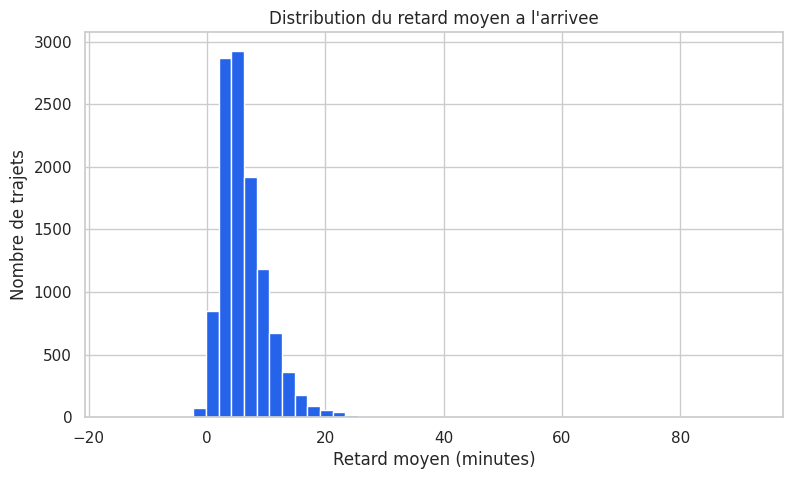

In [27]:
plt.hist(df["avg_delay_all_arr"], bins=50, color=COULEUR, edgecolor="white")

plt.title("Distribution du retard moyen a l'arrivee")
plt.xlabel("Retard moyen (minutes)")
plt.ylabel("Nombre de trajets")
plt.show()

#### Interpretation

La distribution est asymetrique. La grande majorite des trajets se situe entre 2
et 10 minutes de retard, avec un pic autour de 5 minutes. La queue a droite est
longue mais peu peuplee : ce sont les mois exceptionnels, greve ou incident
majeur.

Consequence pour le Step 3 : la variable a predire n'etant pas symetrique, il
faudra regarder l'erreur absolue moyenne, le MAE, autant que le RMSE. Le RMSE
eleve les erreurs au carre, il est donc domine par ces quelques valeurs extremes.

### 14.2 Boite a moustaches

`sns.boxplot()` resume la meme distribution autrement. La boite va du premier au
troisieme quartile, donc contient la moitie centrale des observations. Le trait
au milieu est la mediane. Les points traces au dela des moustaches sont les
valeurs jugees extremes.

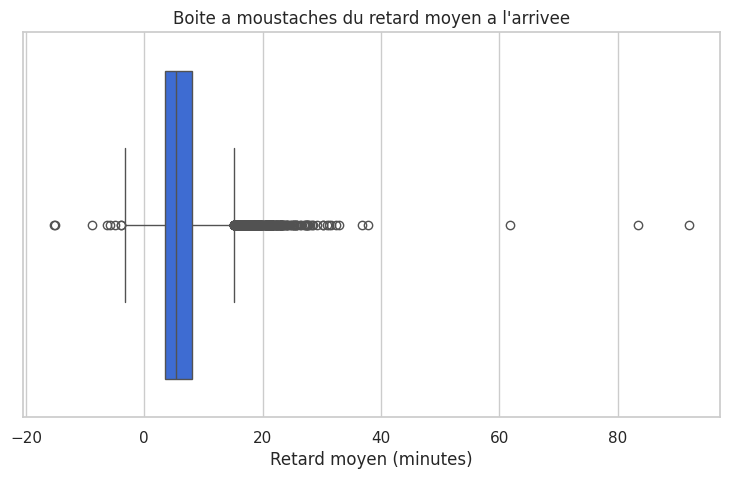

In [28]:
sns.boxplot(x=df["avg_delay_all_arr"], color=COULEUR)

plt.title("Boite a moustaches du retard moyen a l'arrivee")
plt.xlabel("Retard moyen (minutes)")
plt.show()

### 14.3 Effectifs par categorie de retard

`.value_counts()` compte les trajets de chaque categorie, `.sort_index()` les
range dans l'ordre logique Faible, Modere, Important, Critique plutot que par
effectif decroissant.

`plt.bar()` trace un diagramme en barres verticales : `comptage.index` fournit
les noms des categories et `comptage.values` les effectifs.

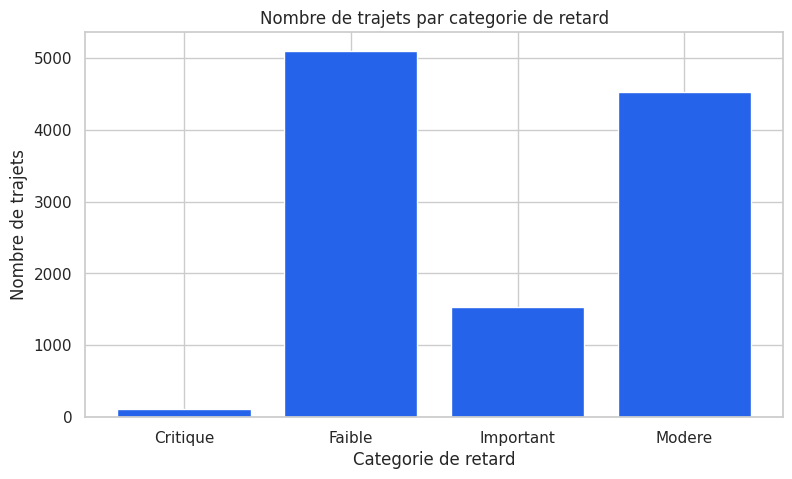

In [29]:
comptage = df["delay_category"].value_counts().sort_index()

plt.bar(comptage.index, comptage.values, color=COULEUR)

plt.title("Nombre de trajets par categorie de retard")
plt.xlabel("Categorie de retard")
plt.ylabel("Nombre de trajets")
plt.show()

#### Interpretation

Environ 85 pour cent des trajets sont en retard faible ou modere, donc sous 10
minutes. Les situations critiques, au dela de 20 minutes, representent a peine
1 pour cent des cas.

Le jeu de donnees est desequilibre. Un modele qui predirait toujours 6 minutes se
tromperait rarement de beaucoup, ce qui explique pourquoi le sujet exige de
battre une baseline plutot que de se contenter d'une erreur faible.

## 15. Comparaison entre gares

### 15.1 Les douze gares les moins ponctuelles

`.groupby("departure_station")["avg_delay_all_arr"].mean()` donne le retard moyen
de chaque gare de depart.

`.sort_values()` trie du plus petit au plus grand, `.tail(12)` prend les douze
dernieres valeurs, donc les douze plus elevees.

`.plot(kind="barh")` trace des barres horizontales. Ce choix n'est pas
esthetique : avec des barres verticales, les noms de gares se chevaucheraient ou
devraient etre inclines.

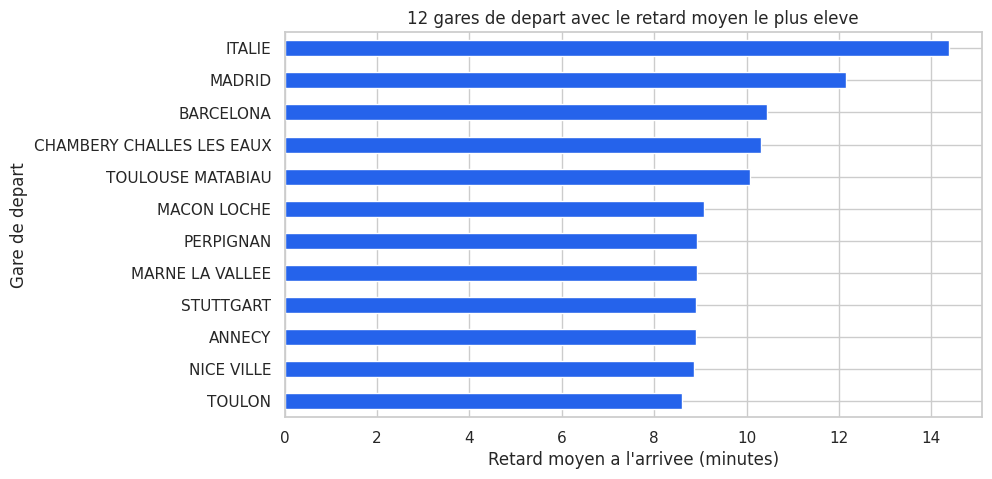

In [30]:
retard_par_gare = df.groupby("departure_station")["avg_delay_all_arr"].mean()

top_gares = retard_par_gare.sort_values().tail(12)

top_gares.plot(kind="barh", color=COULEUR)

plt.title("12 gares de depart avec le retard moyen le plus eleve")
plt.xlabel("Retard moyen a l'arrivee (minutes)")
plt.ylabel("Gare de depart")
plt.show()

### 15.2 Les douze gares les plus ponctuelles

Meme graphique, mais `.head(12)` prend les douze premieres valeurs du tri
croissant, donc les douze plus faibles retards.

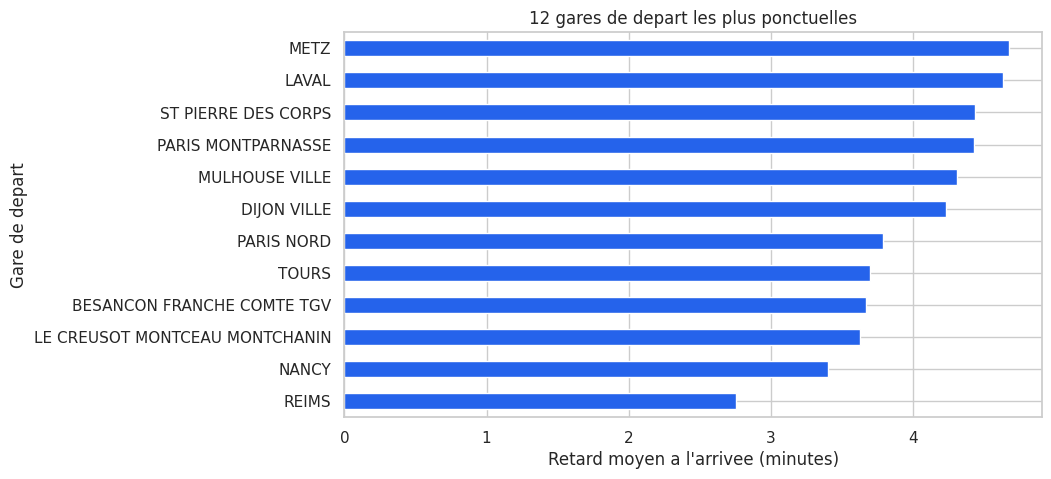

In [31]:
meilleures_gares = retard_par_gare.sort_values().head(12)

meilleures_gares.plot(kind="barh", color=COULEUR)

plt.title("12 gares de depart les plus ponctuelles")
plt.xlabel("Retard moyen a l'arrivee (minutes)")
plt.ylabel("Gare de depart")
plt.show()

#### Interpretation

L'ecart entre les deux graphiques est net : Italie 14,4 minutes, Madrid 12,1 et
Barcelone 10,4 sont en tete, alors que Reims 2,8, Nancy 3,4 et Le Creusot 3,6
restent sous 4 minutes.

Deux facteurs se cumulent, les longues distances et les liaisons
transfrontalieres, qui accumulent les aleas sur le parcours. La gare de depart
est confirmee comme variable explicative importante.

## 16. Effet du temps

### 16.1 Retard moyen par mois de l'annee

`.groupby("month")` regroupe toutes les annees confondues par numero de mois, ce
qui fait apparaitre le cycle saisonnier.

`plt.plot(..., marker="o")` trace une courbe avec un point sur chaque valeur. La
courbe convient ici parce que les mois se suivent dans un ordre naturel, ce qui
n'est pas le cas des gares.

`plt.xticks(range(1, 13))` force l'affichage des douze numeros de mois sur l'axe
horizontal, sinon matplotlib n'en affiche que quelques-uns.

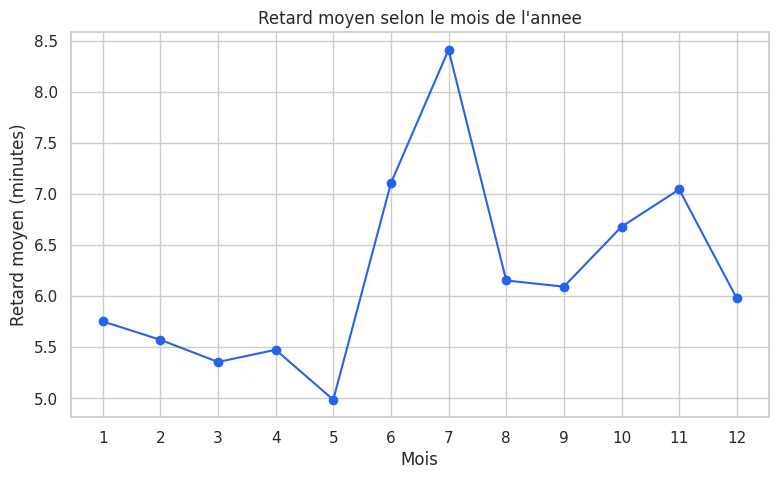

In [32]:
retard_par_mois = df.groupby("month")["avg_delay_all_arr"].mean()

plt.plot(retard_par_mois.index, retard_par_mois.values, marker="o", color=COULEUR)

plt.title("Retard moyen selon le mois de l'annee")
plt.xlabel("Mois")
plt.ylabel("Retard moyen (minutes)")
plt.xticks(range(1, 13))
plt.show()

#### Interpretation

Le retard suit un cycle annuel net : creux en mai a 5,0 minutes, pic en juillet a
8,4 minutes, remontee secondaire en novembre. Juillet cumule le trafic de
vacances et les travaux d'ete sur le reseau.

Le mois est donc une variable temporelle utile pour la prediction.

### 16.2 Evolution par annee

`.groupby("year")` regroupe cette fois par annee civile, ce qui montre la
tendance de fond plutot que le cycle saisonnier.

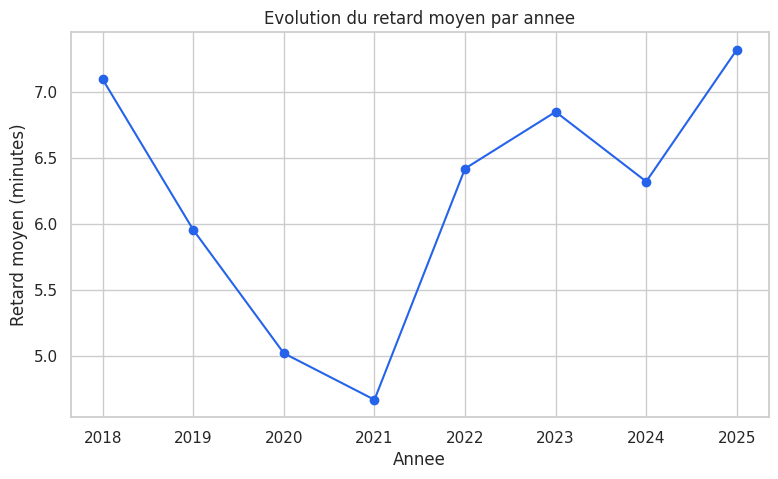

In [33]:
retard_par_annee = df.groupby("year")["avg_delay_all_arr"].mean()

plt.plot(retard_par_annee.index, retard_par_annee.values, marker="o", color=COULEUR)

plt.title("Evolution du retard moyen par annee")
plt.xlabel("Annee")
plt.ylabel("Retard moyen (minutes)")
plt.show()

#### Interpretation

Le retard baisse de 7,1 minutes en 2018 a 4,7 minutes en 2021, puis remonte
regulierement jusqu'a 7,3 minutes en 2025.

Le creux de 2020 et 2021 correspond a la periode de trafic fortement reduit :
moins de trains en circulation, donc moins de retards en cascade. Ces deux annees
ne sont pas representatives du fonctionnement normal du reseau, ce qui compte si
le Step 3 utilise une decoupe temporelle entre entrainement et test.

### 16.3 Retard moyen par saison

`.reindex()` impose l'ordre des saisons. Sans lui, pandas range les groupes par
ordre alphabetique et affiche Automne, Ete, Hiver, Printemps, ce qui n'a aucun
sens sur un axe.

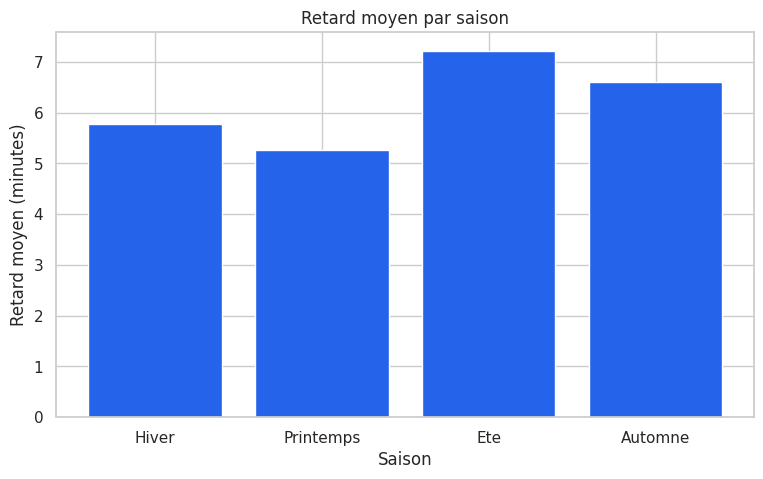

In [34]:
retard_par_saison = df.groupby("season")["avg_delay_all_arr"].mean()
retard_par_saison = retard_par_saison.reindex(["Hiver", "Printemps", "Ete", "Automne"])

plt.bar(retard_par_saison.index, retard_par_saison.values, color=COULEUR)

plt.title("Retard moyen par saison")
plt.xlabel("Saison")
plt.ylabel("Retard moyen (minutes)")
plt.show()

#### Interpretation

L'ete a 7,2 minutes et l'automne a 6,6 sont les saisons les plus degradees, le
printemps est la plus fiable a 5,3. L'ecart entre la meilleure et la pire saison
approche 2 minutes, soit environ un tiers du retard moyen.

Remarque sur le sujet : il demande de comparer les retards selon l'heure de la
journee. Ce n'est pas possible ici, le dataset est mensuel et ne contient ni
horaire ni jour precis. Les variables temporelles disponibles sont le mois, le
trimestre, la saison et l'annee.

## 17. Autres comparaisons

### 17.1 Selon le type de service

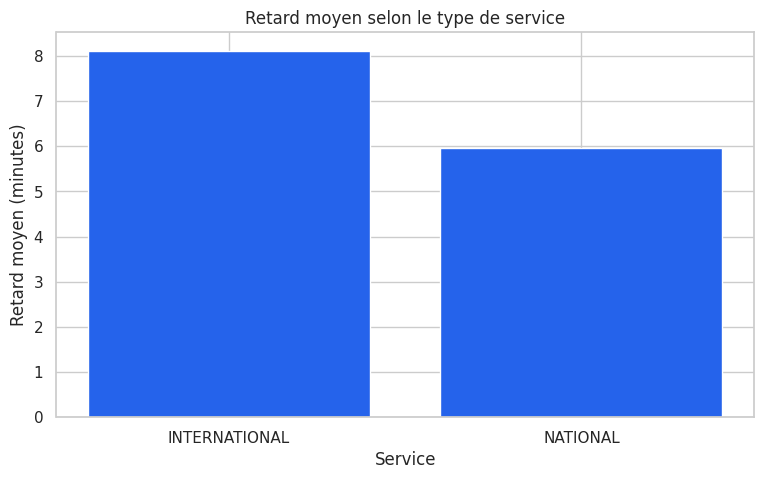

In [35]:
retard_par_service = df.groupby("service")["avg_delay_all_arr"].mean()

plt.bar(retard_par_service.index, retard_par_service.values, color=COULEUR)

plt.title("Retard moyen selon le type de service")
plt.xlabel("Service")
plt.ylabel("Retard moyen (minutes)")
plt.show()

### 17.2 Selon la duree du trajet

L'argument `observed=True` dans le `groupby` concerne les colonnes de type
categoriel creees par `pd.cut` au Step 1 : il demande de ne garder que les
categories reellement presentes dans les donnees.

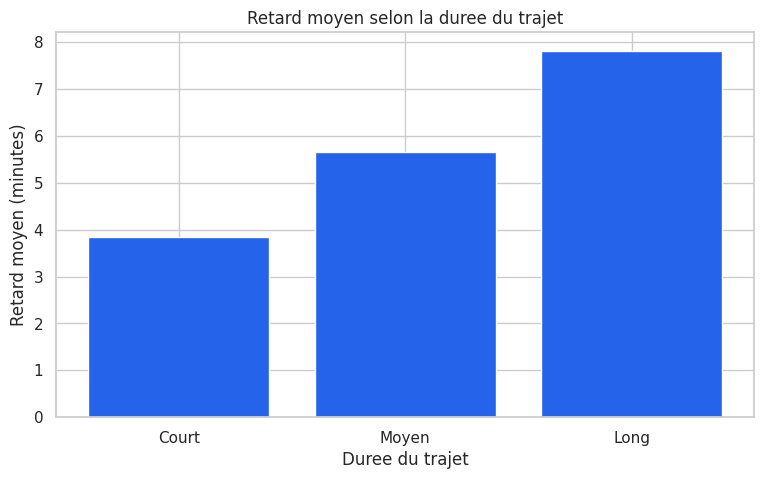

In [36]:
retard_par_duree = df.groupby("journey_length", observed=True)[
    "avg_delay_all_arr"
].mean()
retard_par_duree = retard_par_duree.reindex(["Court", "Moyen", "Long"])

plt.bar(retard_par_duree.index, retard_par_duree.values, color=COULEUR)

plt.title("Retard moyen selon la duree du trajet")
plt.xlabel("Duree du trajet")
plt.ylabel("Retard moyen (minutes)")
plt.show()

#### Interpretation

Les trains internationaux accusent 8,1 minutes de retard moyen contre 6,0 pour
les trains nationaux, soit 36 pour cent de plus.

L'effet de la duree est encore plus marque : 3,9 minutes pour les trajets courts
de moins d'une heure trente, 7,8 minutes pour les longs de plus de trois heures,
soit le double. Plus le trajet est long, plus il y a d'occasions de perdre du
temps.

### 17.3 Nuage de points duree et retard

`plt.scatter()` trace un nuage de points, chaque point etant un trajet. La duree
est en abscisse, le retard en ordonnee.

`alpha=0.3` rend les points transparents : la ou beaucoup de points se
superposent, la zone apparait plus foncee, ce qui revele la densite. `s=10`
reduit la taille des points, indispensable avec 11 000 observations.

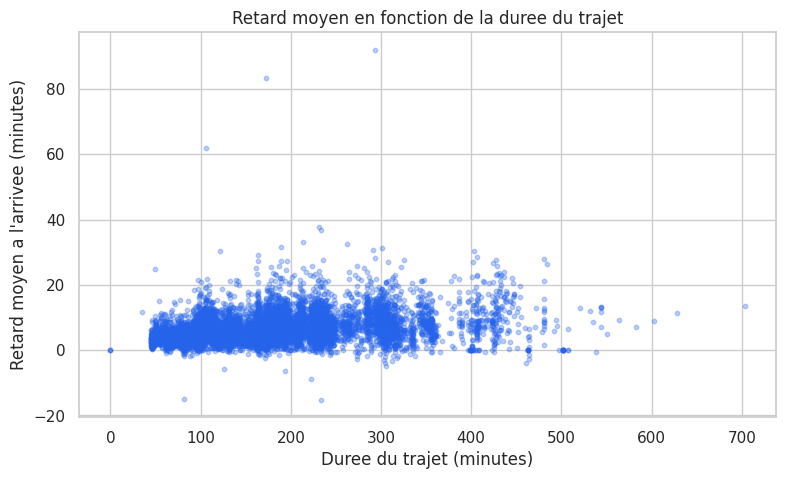

In [37]:
plt.scatter(df["journey_time"], df["avg_delay_all_arr"], alpha=0.3, s=10, color=COULEUR)

plt.title("Retard moyen en fonction de la duree du trajet")
plt.xlabel("Duree du trajet (minutes)")
plt.ylabel("Retard moyen a l'arrivee (minutes)")
plt.show()

#### Interpretation

Le nuage confirme le lien : il s'etale vers le haut quand la duree augmente.

La relation existe mais elle est diffuse. La duree seule ne suffit pas a predire
le retard, elle ne fait qu'elargir l'eventail des retards possibles.

## 18. Causes des retards

Le dataset attribue chaque retard a six causes, exprimees en pourcentage.
`.mean()` calcule la part moyenne de chaque cause sur l'ensemble des trajets, et
`.sort_values()` trie du plus petit au plus grand pour que les barres soient
lisibles de bas en haut.

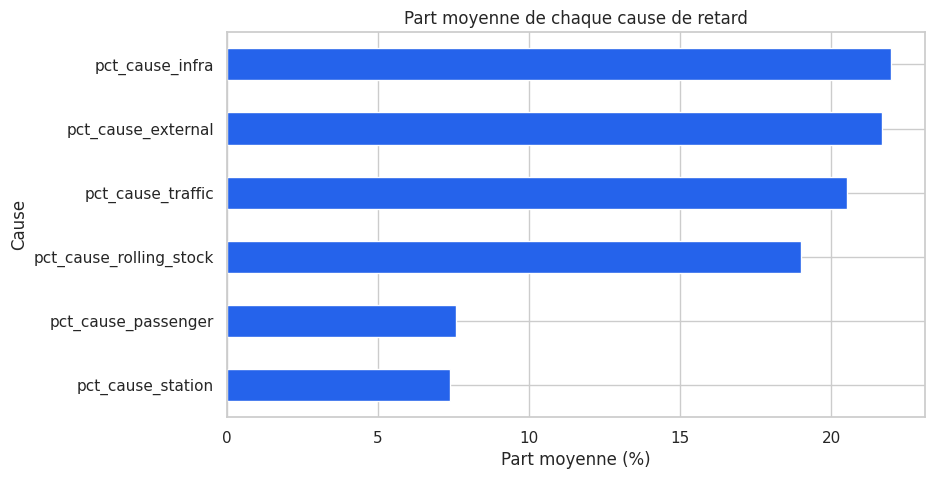

In [38]:
colonnes_causes = [
    "pct_cause_external",
    "pct_cause_infra",
    "pct_cause_traffic",
    "pct_cause_rolling_stock",
    "pct_cause_station",
    "pct_cause_passenger",
]

causes_moyennes = df[colonnes_causes].mean().sort_values()

causes_moyennes.plot(kind="barh", color=COULEUR)

plt.title("Part moyenne de chaque cause de retard")
plt.xlabel("Part moyenne (%)")
plt.ylabel("Cause")
plt.show()

#### Interpretation

Quatre causes se partagent l'essentiel des retards, avec des parts proches :
infrastructure 22 pour cent, causes externes 22, gestion du trafic 20 et materiel
roulant 19. La gestion en gare et l'affluence voyageurs pesent beaucoup moins,
environ 7 chacune.

Aucune cause ne domine. C'est l'explication de fond au fait que le retard est
difficile a predire : il resulte de facteurs multiples et largement independants
des caracteristiques du trajet.

## 19. Correlations

### 19.1 Matrice de correlations

`.corr()` calcule la correlation lineaire entre chaque paire de colonnes. Le
resultat va de -1, les deux variables evoluent en sens inverse, a +1, elles
evoluent ensemble, 0 signifiant aucun lien lineaire.

`sns.heatmap()` colorie chaque case selon sa valeur. `annot=True` ecrit la valeur
dans la case et `fmt=".2f"` l'affiche avec deux decimales.

`cmap="coolwarm"` et `center=0` forment un choix deliberé : une palette divergente
avec le blanc au centre, bleu pour les correlations negatives et rouge pour les
positives. Une palette a une seule couleur melangerait fort negatif et fort
positif.

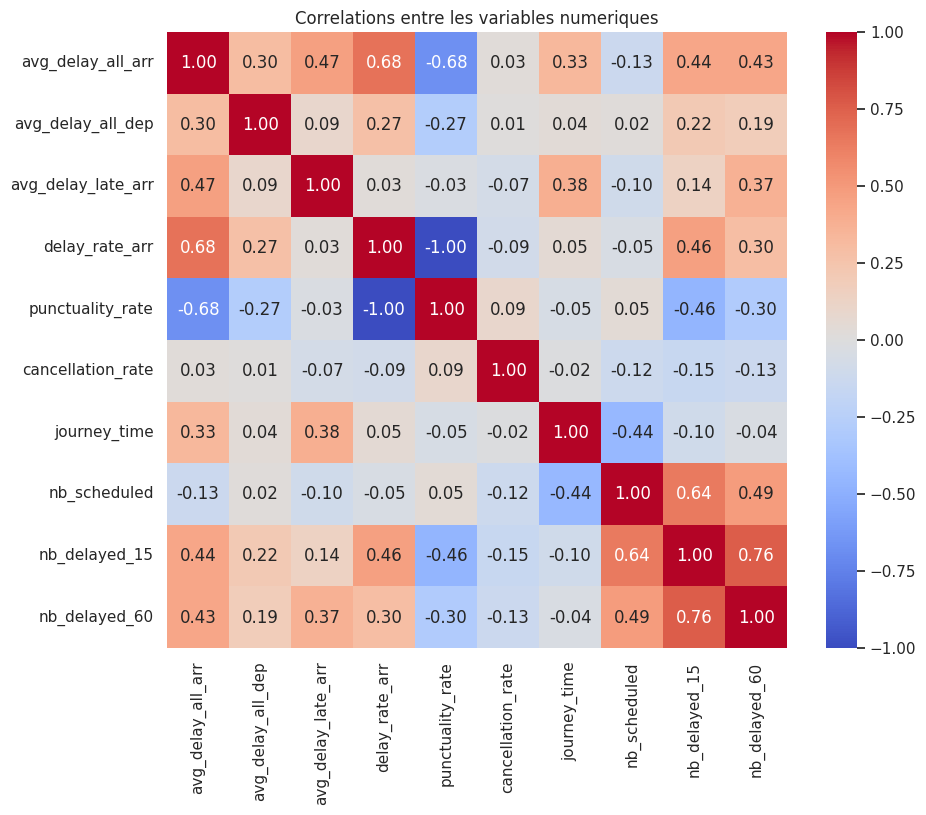

In [39]:
colonnes_corr = [
    "avg_delay_all_arr",
    "avg_delay_all_dep",
    "avg_delay_late_arr",
    "delay_rate_arr",
    "punctuality_rate",
    "cancellation_rate",
    "journey_time",
    "nb_scheduled",
    "nb_delayed_15",
    "nb_delayed_60",
]

matrice = df[colonnes_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matrice, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Correlations entre les variables numeriques")
plt.show()

### 19.2 Correlations avec la variable a predire

On extrait la seule colonne qui nous interesse vraiment, celle de la cible, et on
la trie de la correlation la plus forte a la plus faible.

In [40]:
correlations_cible = matrice["avg_delay_all_arr"].sort_values(ascending=False)

print(correlations_cible.round(2))

avg_delay_all_arr     1.00
delay_rate_arr        0.68
avg_delay_late_arr    0.47
nb_delayed_15         0.44
nb_delayed_60         0.43
journey_time          0.33
avg_delay_all_dep     0.30
cancellation_rate     0.03
nb_scheduled         -0.13
punctuality_rate     -0.68
Name: avg_delay_all_arr, dtype: float64


#### Interpretation

`delay_rate_arr` a +0,68 et `punctuality_rate` a -0,68 sont les plus liees a la
cible, ce qui est mecanique : plus la part de trains en retard est elevee, plus
le retard moyen monte. Ces deux variables sont calculees a partir des memes
trains que la cible, elles feraient fuiter la reponse dans le modele.

`journey_time` a +0,33 confirme l'effet de la duree vu plus haut.

`avg_delay_all_dep` a +0,30 : un train qui part en retard arrive en retard, mais
le lien est loin d'etre total, une partie du retard se cree pendant le trajet.

`nb_scheduled` a -0,13 : les liaisons a fort trafic sont plutot mieux tenues.

Une fois les variables derivees du retard mises de cote, la correlation la plus
forte tombe a 0,33. Il n'existe donc pas de predicteur unique et evident, un
modele multivariable est necessaire.

## 20. Synthese pour le Step 3

Ce que l'analyse etablit, et ce que le modele devra en faire.

1. Le retard moyen a l'arrivee vaut 6,2 minutes, avec une distribution etiree
   vers la droite et quelques valeurs extremes. Presenter MAE et RMSE, commenter
   surtout le MAE.
2. La gare de depart discrimine fortement, de 2,8 a 14,4 minutes selon la gare.
   A garder et a encoder comme variable categorielle.
3. Le mois et la saison ont un effet clair, avec un pic en juillet. A garder.
4. La duree du trajet double le retard entre trajets courts et longs. A garder.
5. Le service international ajoute environ 2 minutes. A garder.
6. Aucune variable ne suffit seule : hors variables derivees du retard, la
   correlation maximale est de 0,33. Un modele a base d'arbres, capable de capter
   des interactions, devrait battre une regression lineaire.
7. `delay_rate_arr`, `punctuality_rate`, `delay_category`, `delay_amplification`
   et les colonnes `nb_delayed_*` sont calculees a partir du retard lui-meme.
   Les utiliser comme predicteurs reviendrait a donner la reponse au modele. Il
   faudra les ecarter des variables d'entree.